### Top Pharmaceuticals payment data analysis

* Goal: Analysis of gender based payment disparity in pharmaceutical industry
* Scope General data - Segmentation and analysis of Novo Nordisk
* Subsidiaries considerd: Novo Nordisk as, Novo Nordisk
* Date: 20 November 2024


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df_dashboard=pd.read_csv("dashboard_dataset_nov17.csv", low_memory=False)

In [ ]:
df_dashboard.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6673533 entries, 0 to 6673532
Data columns (total 33 columns):
 #   Column                                                             Dtype  
---  ------                                                             -----  
 0   Unnamed: 0                                                         int64  
 1   Covered_Recipient_Type                                             object 
 2   Teaching_Hospital_Name                                             object 
 3   Covered_Recipient_Profile_ID                                       float64
 4   Covered_Recipient_First_Name                                       object 
 5   Covered_Recipient_Last_Name                                        object 
 6   Covered_Recipient_Primary_Type_1                                   object 
 7   Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name      object 
 8   Total_Amount_of_Payment_USDollars                                  float64
 9   Nu

In [ ]:
df_dashboard=df_dashboard.drop(['Unnamed: 0'], axis=1)


In [ ]:
df_dashboard['Covered_Recipient_Profile_ID']=df_dashboard['Covered_Recipient_Profile_ID'].astype('object')
df_dashboard.describe()

,Total_Amount_of_Payment_USDollars,Number_of_Payments_Included_in_Total_Amount,Average_payment
count,6.673533e+06,6.673533e+06,6.673533e+06
mean,1.701051e+02,1.023259e+00,1.699443e+02
std,5.890177e+04,5.954720e-01,5.890177e+04
min,1.000000e-02,1.000000e+00,1.000000e-02
25%,1.392000e+01,1.000000e+00,1.388000e+01
50%,1.789000e+01,1.000000e+00,1.784000e+01
75%,2.337000e+01,1.000000e+00,2.330000e+01
max,8.837730e+07,1.270000e+02,8.837730e+07


In [ ]:
# To run for each company by replacing df with df_mycom

In [ ]:
df_dashboard['Parent_Manufacturer_or_GPO'].unique()


array(['merck', 'astrazeneca', 'novartis', 'abbvie', 'pfizer',
       'johnson & johnson', 'roche', 'gsk', 'bristol myers squibb',
       'gilead', 'vertex', 'novo nordisk', 'eli lilly', 'sanofi',
       'bayer healthcare', 'amgen', 'boehringer',
       'regeneron pharmaceuticals', 'modernatx', 'biontech'], dtype=object)

In [ ]:
df_mycom=df_dashboard[df_dashboard['Parent_Manufacturer_or_GPO']=='novo nordisk']
my_com='novo nordisk'

In [ ]:
### Master set for querying every company

# Total amount and number of transactions
print("Total amount of payments processed in USD for the year 2023 for "+ my_com, df_mycom['Total_Amount_of_Payment_USDollars'].sum(), '$')
print("total number of transactions processed in 2023 for " +my_com, df_mycom['Number_of_Payments_Included_in_Total_Amount'].sum())


Total amount of payments processed in USD for the year 2023 for novo nordisk 23761442.290000007 $
total number of transactions processed in 2023 for novo nordisk 485640


In [ ]:
# Number of individuals paid using profile ID
print("The number of individuals paid:", df_mycom['Covered_Recipient_Profile_ID'].nunique())

The number of individuals paid: 101281


In [ ]:
# Number of third parites reciving payments
print("Number of third parties receiving payments", df_mycom['Name_of_Third_Party_Entity_Receiving_Payment_or_Transfer_of_Value'].nunique())


Number of third parties receiving payments 187


In [ ]:
# All the covered recipient types
df_mycom['Covered_Recipient_Type'].unique()

array(['Covered Recipient Physician',
       'Covered Recipient Non-Physician Practitioner',
       'Covered Recipient Teaching Hospital'], dtype=object)

In [ ]:
df_mycom['Covered_Recipient_Type'].value_counts()


,count
Covered_Recipient_Type,
Covered Recipient Physician,283338
Covered Recipient Non-Physician Practitioner,202294
Covered Recipient Teaching Hospital,8


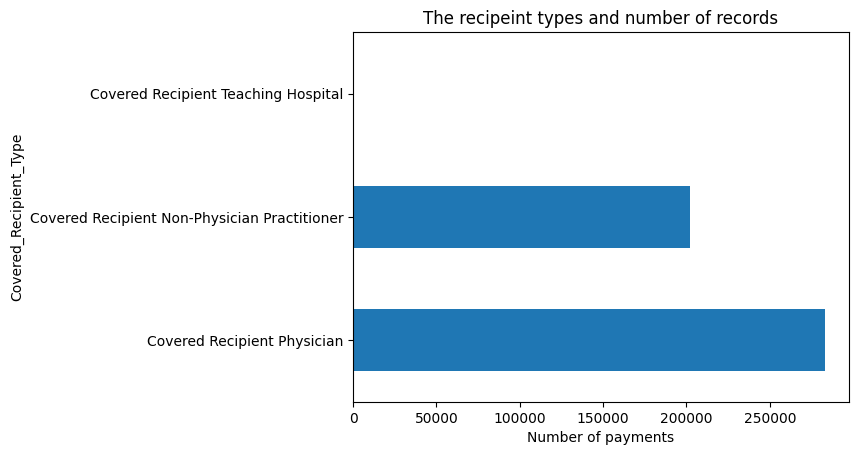

In [ ]:
# Covered recipient types and numer of payment records
plt.title('The recipeint types and number of records');
df_mycom['Covered_Recipient_Type'].value_counts().plot(kind='barh')
plt.xlabel('Number of payments');


In [ ]:
# Recipient types and total amount pain to each type
df_mycom.groupby('Covered_Recipient_Type')['Total_Amount_of_Payment_USDollars'].sum().reset_index()


,Covered_Recipient_Type,Total_Amount_of_Payment_USDollars
0,Covered Recipient Non-Physician Practitioner,4913386.21
1,Covered Recipient Physician,18831356.08
2,Covered Recipient Teaching Hospital,16700.00


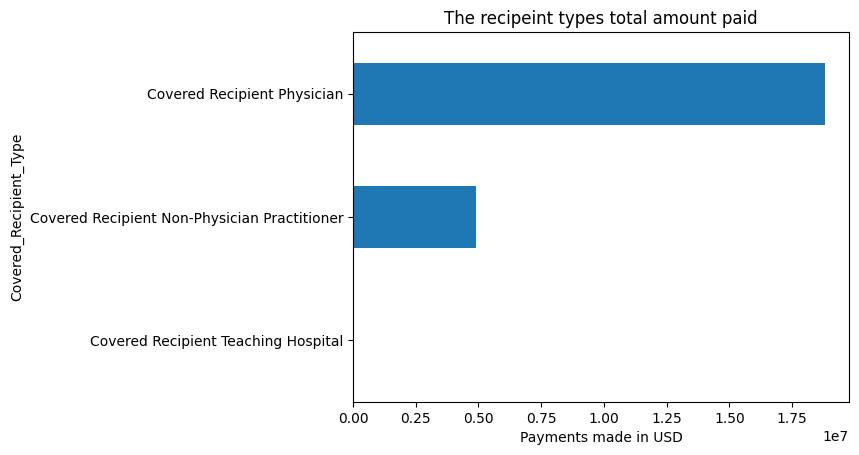

In [ ]:
# Covered recipient types and payment amount

plt.title('The recipeint types total amount paid');
df_mycom.groupby('Covered_Recipient_Type')['Total_Amount_of_Payment_USDollars'].sum().sort_values().plot(kind='barh')
plt.xlabel('Payments made in USD');


In [ ]:
# Payment to teaching hospitals
print("The number of teaching hospitals paid:", df_mycom['Teaching_Hospital_Name'].nunique())


The number of teaching hospitals paid: 7


In [ ]:
# Teaching hospitals and related paymants
top_teaching=df_mycom.groupby(['Covered_Recipient_Type', 'Teaching_Hospital_Name'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
top_teaching.Teaching_Hospital_Name.describe()



,Teaching_Hospital_Name
count,7
unique,7
top,the christ hospital
freq,1


In [ ]:
# Teaching hospitals sorted by total payment amount
print("Teaching hospitals and total payments")
top_teaching


Teaching hospitals and total payments


,Covered_Recipient_Type,Teaching_Hospital_Name,Total_Amount_of_Payment_USDollars
0,Covered Recipient Teaching Hospital,the christ hospital,5000.0
1,Covered Recipient Teaching Hospital,ohsu hospital and clinics,4000.0
2,Covered Recipient Teaching Hospital,the ohio state university hospital,3000.0
3,Covered Recipient Teaching Hospital,uh cleveland medical center,1750.0
4,Covered Recipient Teaching Hospital,henry ford hospital,1500.0
5,Covered Recipient Teaching Hospital,vanderbilt university medical center,750.0
6,Covered Recipient Teaching Hospital,board of trustees of the university,700.0


In [ ]:
# identifying unique individuals using profile ID.
print("Total individuals by profile paid:", df_mycom['Covered_Recipient_Profile_ID'].nunique())



Total individuals by profile paid: 101281


In [ ]:
print("Gender distribution in healthcare dataset")
gender_dist=df_mycom.groupby(['Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index()
gender_dist



Gender distribution in healthcare dataset


,Covered_Recipient_gender,Covered_Recipient_Profile_ID
0,F,58536
1,M,42741


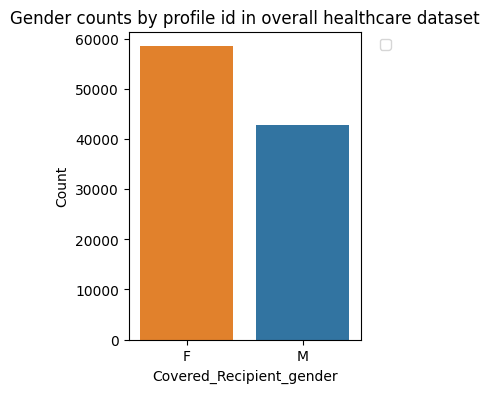

In [ ]:
# Plot for gender distribution
my_palette ={"F": "C1", "M": "C0"}
g=sns.barplot(data=gender_dist, x='Covered_Recipient_gender', y='Covered_Recipient_Profile_ID', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender counts by profile id in overall healthcare dataset")
g.figure.set_size_inches(3, 4)
plt.ylabel("Count")
# Place the legend outside the plot
plt.xticks
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');



In [ ]:
print("Gender distribution by physicians and non-physicians in Covered recipients")
gender_dist_recipients=df_mycom.groupby(['Covered_Recipient_Type','Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index()
gender_dist_recipients

Gender distribution by physicians and non-physicians in Covered recipients


,Covered_Recipient_Type,Covered_Recipient_gender,Covered_Recipient_Profile_ID
0,Covered Recipient Non-Physician Practitioner,F,37450
1,Covered Recipient Non-Physician Practitioner,M,8188
2,Covered Recipient Physician,F,21087
3,Covered Recipient Physician,M,34553


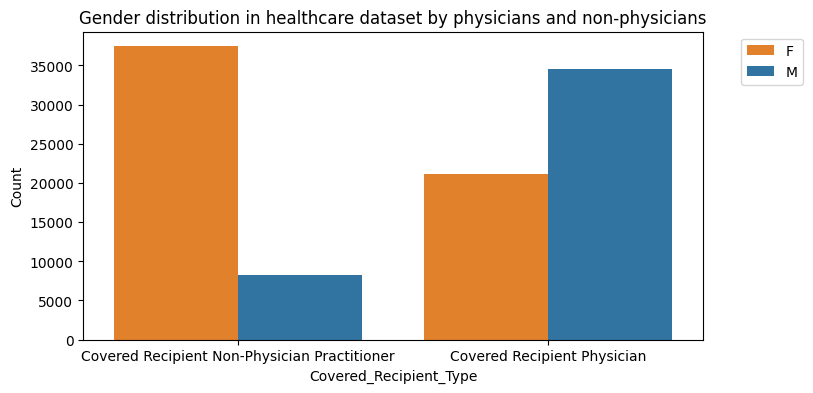

In [ ]:
# Plot for gender distribution
g=sns.barplot(data=gender_dist_recipients, x='Covered_Recipient_Type', y='Covered_Recipient_Profile_ID', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender distribution in healthcare dataset by physicians and non-physicians")
g.figure.set_size_inches(8, 4)
plt.ylabel("Count")
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');



In [ ]:
print("Gender distribution amongst physician categories")
gender_dist_physicians=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Primary_Type_1','Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index()
gender_dist_physicians



Gender distribution amongst physician categories


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Covered_Recipient_Profile_ID
0,Chiropractor,F,9
1,Chiropractor,M,34
2,Doctor of Dentistry,F,29
3,Doctor of Dentistry,M,31
4,Doctor of Optometry,F,23
5,Doctor of Optometry,M,16
6,Doctor of Osteopathy,F,3814
7,Doctor of Osteopathy,M,5569
8,Doctor of Podiatric Medicine,F,39
9,Doctor of Podiatric Medicine,M,79


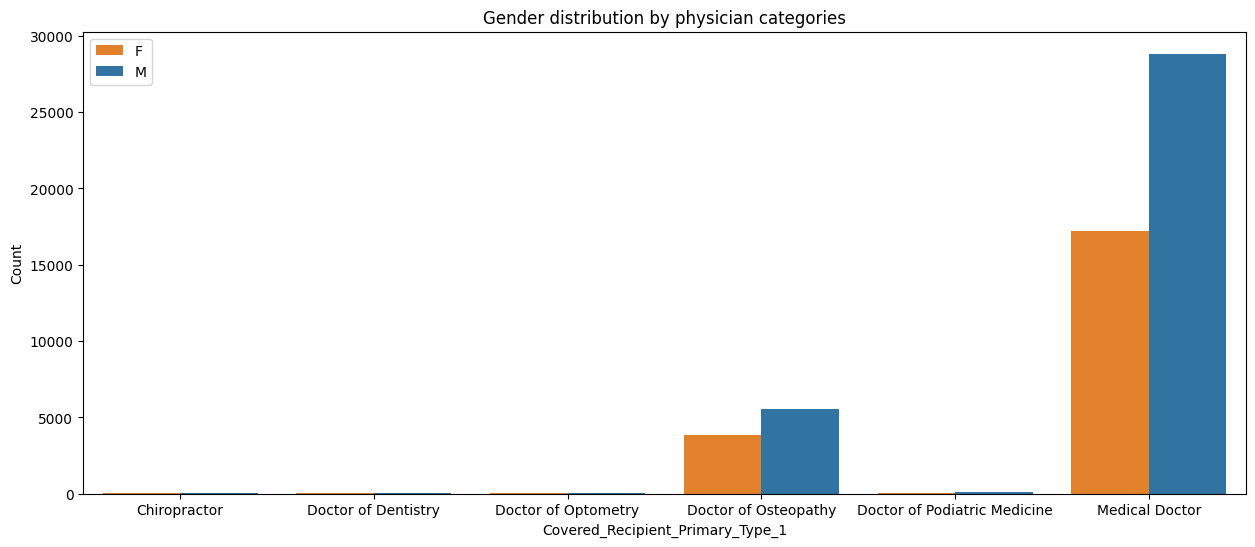

In [ ]:
# Plot for gender distribution
g=sns.barplot(data=gender_dist_physicians, x='Covered_Recipient_Primary_Type_1', y='Covered_Recipient_Profile_ID', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender distribution by physician categories")
g.figure.set_size_inches(15, 6)
plt.ylabel("Count")
# Place the legend outside the plot
plt.legend(loc='upper left');



In [ ]:
print("Gender distribution amongst non-physician categories")
gender_dist_non_physicians=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner'].groupby(['Covered_Recipient_Primary_Type_1','Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index()
gender_dist_non_physicians



Gender distribution amongst non-physician categories


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Covered_Recipient_Profile_ID
0,Certified Nurse-Midwife,F,71
1,Certified Nurse-Midwife,M,3
2,Certified Registered Nurse Anesthetist,F,30
3,Certified Registered Nurse Anesthetist,M,10
4,Clinical Nurse Specialist,F,55
5,Clinical Nurse Specialist,M,7
6,Nurse Practitioner,F,28827
7,Nurse Practitioner,M,4682
8,Physician Assistant,F,8467
9,Physician Assistant,M,3486


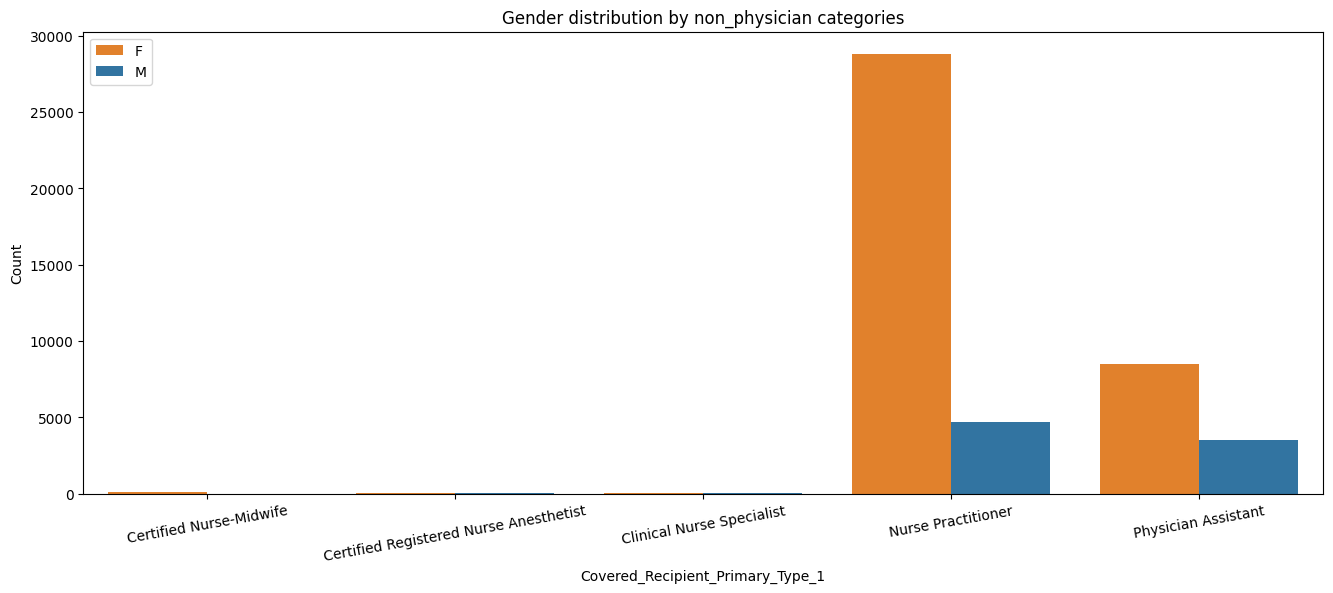

In [ ]:
# Plot for gender distribution
g=sns.barplot(data=gender_dist_non_physicians, x='Covered_Recipient_Primary_Type_1', y='Covered_Recipient_Profile_ID', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender distribution by non_physician categories")
g.figure.set_size_inches(16, 6)
plt.ylabel("Count")
plt.xticks(rotation=10)
# Place the legend outside the plot
plt.legend(loc='upper left');



In [ ]:
# Covered recipient types and total payments to each type by gender
print("Total payments by recipients gender")
recipient_gender_payments=df_mycom.groupby(['Covered_Recipient_Type','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index();
recipient_gender_payments


Total payments by recipients gender


,Covered_Recipient_Type,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,Covered Recipient Physician,M,12319207.48
1,Covered Recipient Physician,F,6510050.26
2,Covered Recipient Non-Physician Practitioner,F,4065120.07
3,Covered Recipient Non-Physician Practitioner,M,848204.63


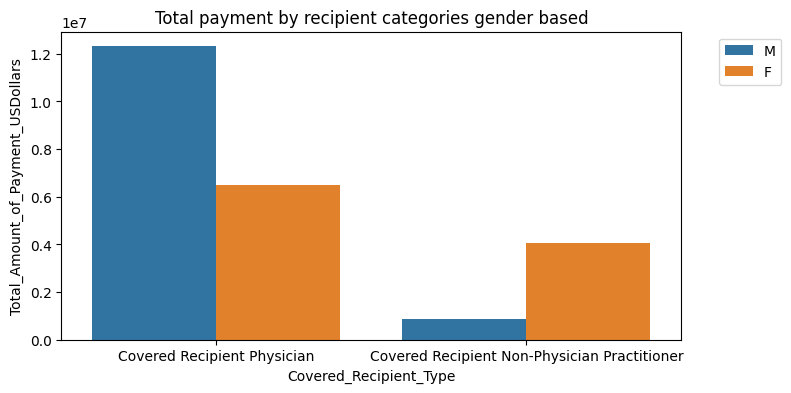

In [ ]:
# Plot for gender distribution
g=sns.barplot(data=recipient_gender_payments, x='Covered_Recipient_Type', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', palette=my_palette).set_title("Total payment by recipient categories gender based")
g.figure.set_size_inches(8, 4)

# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');



## Total payment physicians

In [ ]:
### Total payment split physician profiles
print("The total payment for physician profiles")
physicians_total_payments=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Primary_Type_1'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
physicians_total_payments



The total payment for physician profiles


,Covered_Recipient_Primary_Type_1,Total_Amount_of_Payment_USDollars
0,Medical Doctor,17002444.01
1,Doctor of Osteopathy,1817654.36
2,Doctor of Podiatric Medicine,5289.42
3,Doctor of Dentistry,2867.67
4,Chiropractor,1582.93
5,Doctor of Optometry,1517.69


In [ ]:
### Total payment split physician profiles by gender
print("The total payment for physician profiles")
physicians_gender_total_payments=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Primary_Type_1', 'Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
physicians_gender_total_payments



The total payment for physician profiles


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,Medical Doctor,M,11245940.63
1,Medical Doctor,F,5754405.04
2,Doctor of Osteopathy,M,1066953.24
3,Doctor of Osteopathy,F,750701.12
4,Doctor of Podiatric Medicine,M,3265.68
5,Doctor of Podiatric Medicine,F,2023.74
6,Doctor of Dentistry,F,1500.86
7,Doctor of Dentistry,M,1366.81
8,Chiropractor,M,1123.61
9,Doctor of Optometry,F,960.18


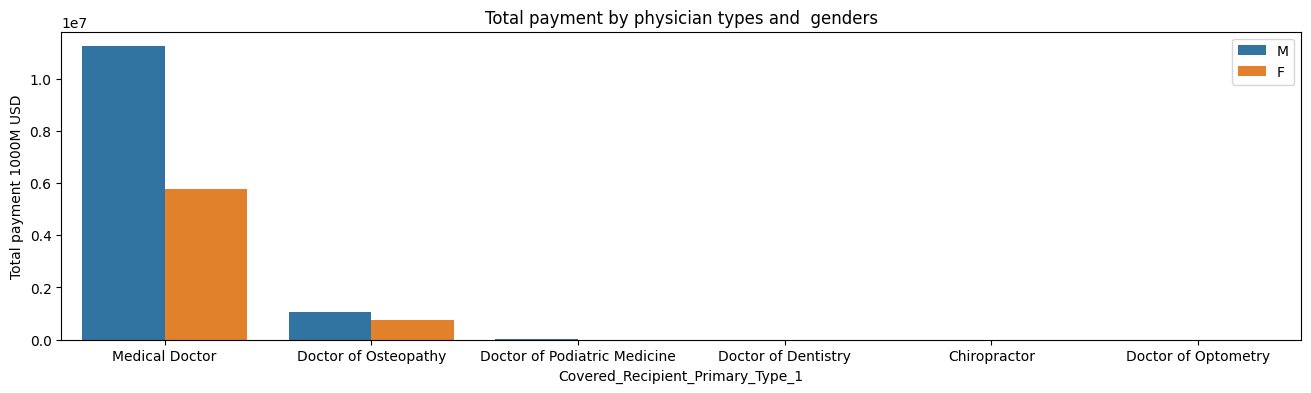

In [ ]:
# Plot for gender distribution
g=sns.barplot(data=physicians_gender_total_payments, x='Covered_Recipient_Primary_Type_1', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', palette=my_palette).set_title("Total payment by physician types and  genders")
g.figure.set_size_inches(16, 4)
plt.ylabel("Total payment 1000M USD")
# Place the legend outside the plot
plt.legend( loc='upper right');



## Average payments

In [ ]:
# Average payment per recipient type.
print("The average payment by per transaction recipient category")
avg=df_mycom.groupby(['Covered_Recipient_Type'])['Average_payment'].mean()
avg


The average payment by per transaction recipient category


,Average_payment
Covered_Recipient_Type,
Covered Recipient Non-Physician Practitioner,24.288344
Covered Recipient Physician,66.462515
Covered Recipient Teaching Hospital,2087.500000


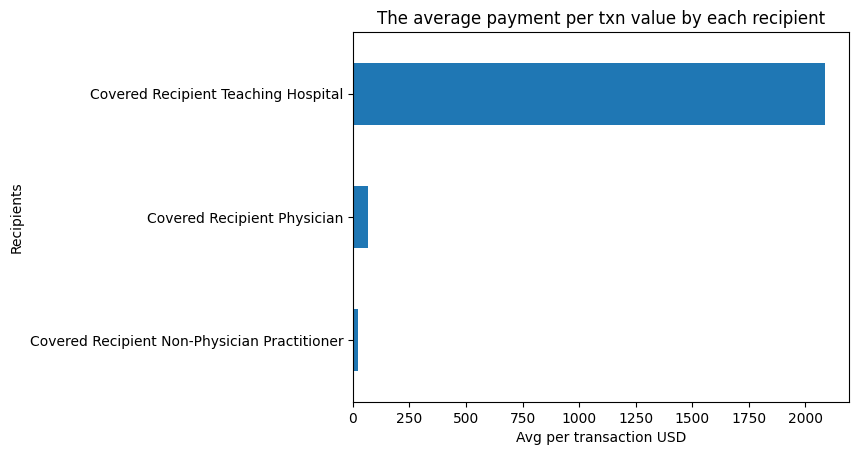

In [ ]:
## Plot for average payment per recipient group type
plt.title("The average payment per txn value by each recipient")
avg.plot(kind='barh')
plt.xlabel('Avg per transaction USD')
plt.ylabel('Recipients');


In [ ]:
##  Average payment per recipient physician primary 1 type gender based
print('Gender based average per transaction payment  for recipient types')
gender_recipients_avg=df_mycom.groupby(['Covered_Recipient_Type','Covered_Recipient_gender'])['Average_payment'].mean().sort_values(ascending=False).reset_index()

gender_recipients_avg



Gender based average per transaction payment  for recipient types


,Covered_Recipient_Type,Covered_Recipient_gender,Average_payment
0,Covered Recipient Physician,M,67.400206
1,Covered Recipient Physician,F,64.748272
2,Covered Recipient Non-Physician Practitioner,F,24.948264
3,Covered Recipient Non-Physician Practitioner,M,21.556486


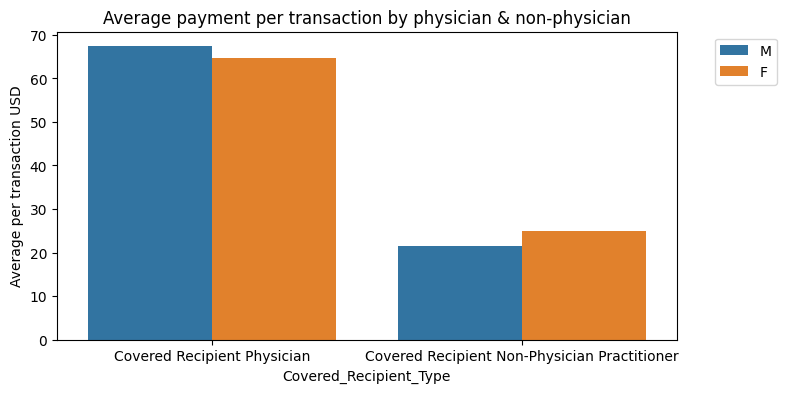

In [ ]:
# Plot for gender distribution
g=sns.barplot(data=gender_recipients_avg, x='Covered_Recipient_Type', y='Average_payment', hue='Covered_Recipient_gender', palette=my_palette).set_title("Average payment per transaction by physician & non-physician")
g.figure.set_size_inches(8, 4)
plt.ylabel("Average per transaction USD")
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');



In [ ]:
##  Average payment per recipient physician primary 1 type gender based
print('Gender based average transaction value for physician categories')
gender_recipients_avg_payments=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Primary_Type_1','Covered_Recipient_gender'])['Average_payment'].mean().sort_values(ascending=False).reset_index()
gender_recipients_avg_payments



Gender based average transaction value for physician categories


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Average_payment
0,Medical Doctor,M,74.417288
1,Medical Doctor,F,70.494616
2,Doctor of Dentistry,F,45.480606
3,Chiropractor,F,41.756364
4,Doctor of Dentistry,M,40.200294
5,Doctor of Osteopathy,F,39.977693
6,Doctor of Osteopathy,M,33.951290
7,Doctor of Optometry,F,33.109655
8,Doctor of Podiatric Medicine,F,31.620938
9,Doctor of Optometry,M,27.875500


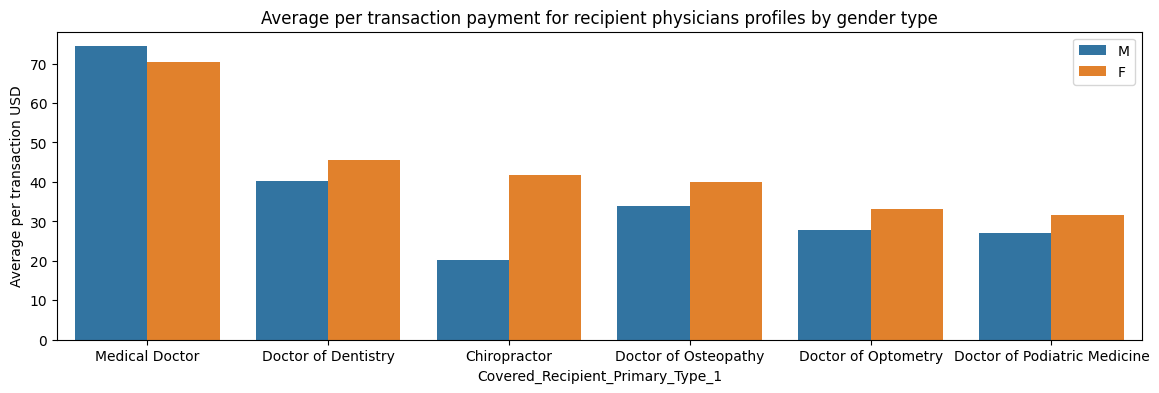

In [ ]:
## Plot for average payment per recipient physician primary 1 type
g=sns.barplot(data=gender_recipients_avg_payments, x='Covered_Recipient_Primary_Type_1', y='Average_payment', hue='Covered_Recipient_gender',palette=my_palette)
g.set_title('Average per transaction payment for recipient physicians profiles by gender type')
g.figure.set_size_inches(14, 4)
plt.ylabel("Average per transaction USD")
# Place the legend outside the plot
plt.legend( loc='upper right');



## Analysis by individuals

In [ ]:
print("Total payment distribution per individual")
ind_tot_payments=df_mycom[df_mycom['Covered_Recipient_Profile_ID'].notna()].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
ind_tot_payments


Total payment distribution per individual


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,684159.0,M,115976.18
1,26487.0,M,111701.80
2,281692.0,M,97454.31
3,959048.0,F,97155.32
4,11337343.0,F,75000.00
...,...,...,...
101272,10787726.0,F,12.69
101273,10623777.0,F,12.69
101274,10741309.0,F,12.69
101275,10701093.0,F,10.54


In [ ]:
### Physicians
print("individual payment distribution")
ind_payments_phys=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
ind_payments_phys


individual payment distribution


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,684159.0,M,115976.18
1,26487.0,M,111701.80
2,281692.0,M,97454.31
3,959048.0,F,97155.32
4,11337343.0,F,75000.00
...,...,...,...
55635,353514.0,M,12.69
55636,807828.0,F,12.69
55637,11447294.0,M,12.69
55638,1380005.0,M,12.69


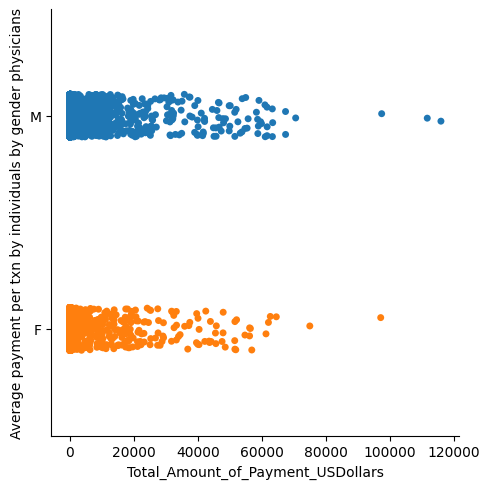

In [ ]:
### Plot for gender distribution for physicians
g=sns.catplot(data=ind_payments_phys, y='Covered_Recipient_gender', x='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', palette=my_palette)
g.set_titles("{col_name} {col_var}")
plt.ylabel("Average payment per txn by individuals by gender physicians");


#### Analysing top 50 individuals by gender

<ipython-input-42-241bd9aa8f15>:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=90);


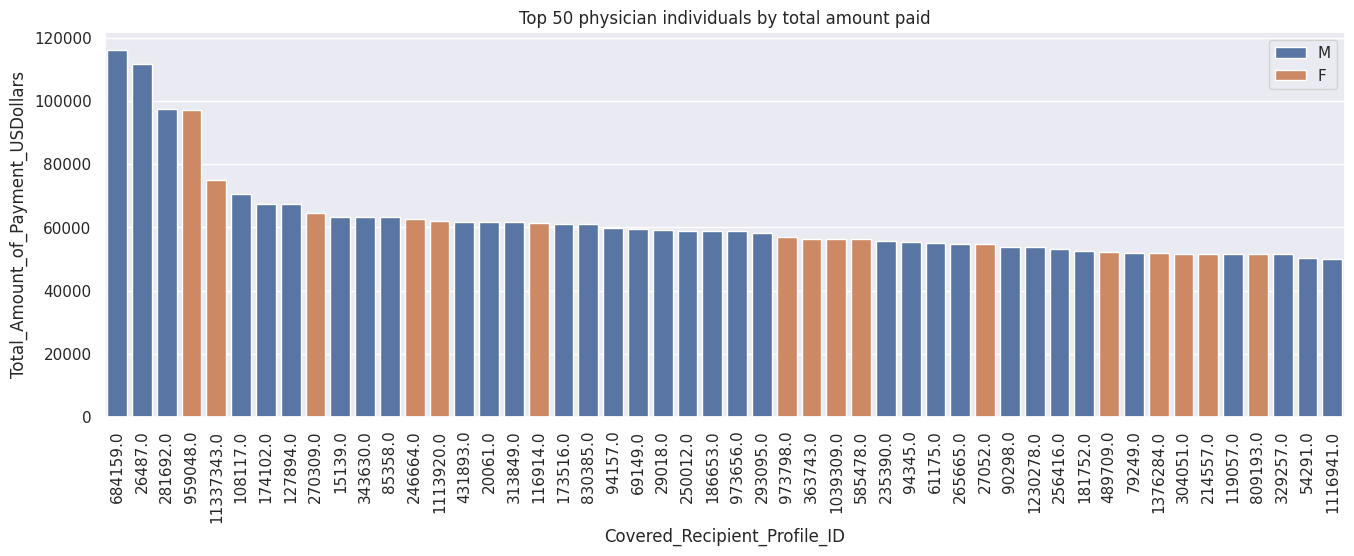

In [ ]:
sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=ind_payments_phys[:50], x='Covered_Recipient_Profile_ID', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender',
              order=ind_payments_phys[:50].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID, palette=my_palette)
g.set(title="Top 50 physician individuals by total amount paid")
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');

## Distribution by nature of payments

In [ ]:
# Distribution by nature of payments to physicians
nature_payments=df_mycom.groupby(['Nature_of_Payment_or_Transfer_of_Value'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nature_payments


,Nature_of_Payment_or_Transfer_of_Value,Total_Amount_of_Payment_USDollars
0,Food and Beverage,8724584.13
1,Other_services,8146318.56
2,Consulting Fee,4879847.50
3,Travel and Lodging,1677208.92
4,Grant,225250.80
5,Education,84532.38
6,Spacerent_teaching_hosp,16700.00
7,Honoraria,7000.00


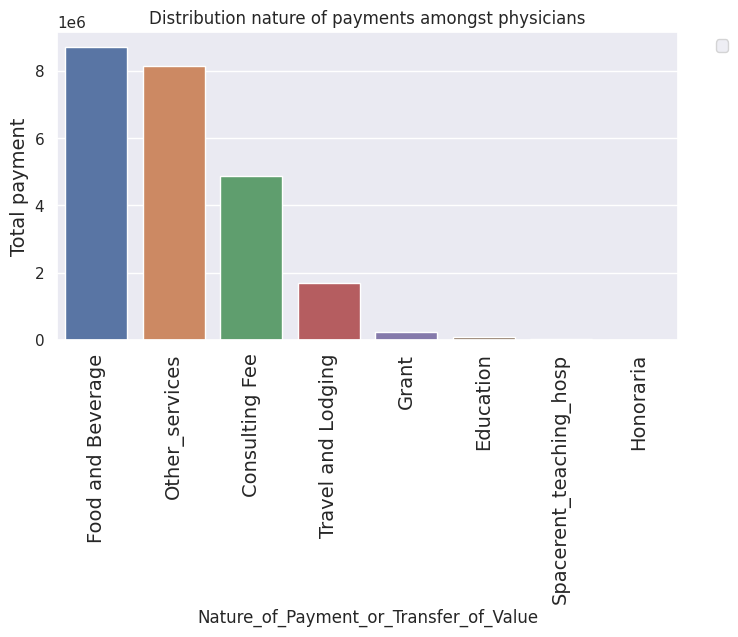

In [ ]:
# Nature of payments made
g=sns.barplot(data=nature_payments, x='Nature_of_Payment_or_Transfer_of_Value', y='Total_Amount_of_Payment_USDollars', hue='Nature_of_Payment_or_Transfer_of_Value').set_title("Distribution nature of payments amongst physicians")
g.figure.set_size_inches(8, 4)
plt.ylabel("Total payment", size=14)
plt.xticks(rotation=90, size=14)
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');


In [ ]:
# Distribution by gender for nature of payments
nature_gender=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Nature_of_Payment_or_Transfer_of_Value','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nature_gender


,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,Other_services,M,5229375.56
1,Food and Beverage,M,3143935.60
2,Consulting Fee,M,2985656.25
3,Other_services,F,2123286.45
4,Food and Beverage,F,1842002.73
5,Consulting Fee,F,1710606.25
6,Travel and Lodging,M,899011.50
7,Travel and Lodging,F,598761.83
8,Grant,F,205516.80
9,Education,M,39494.57


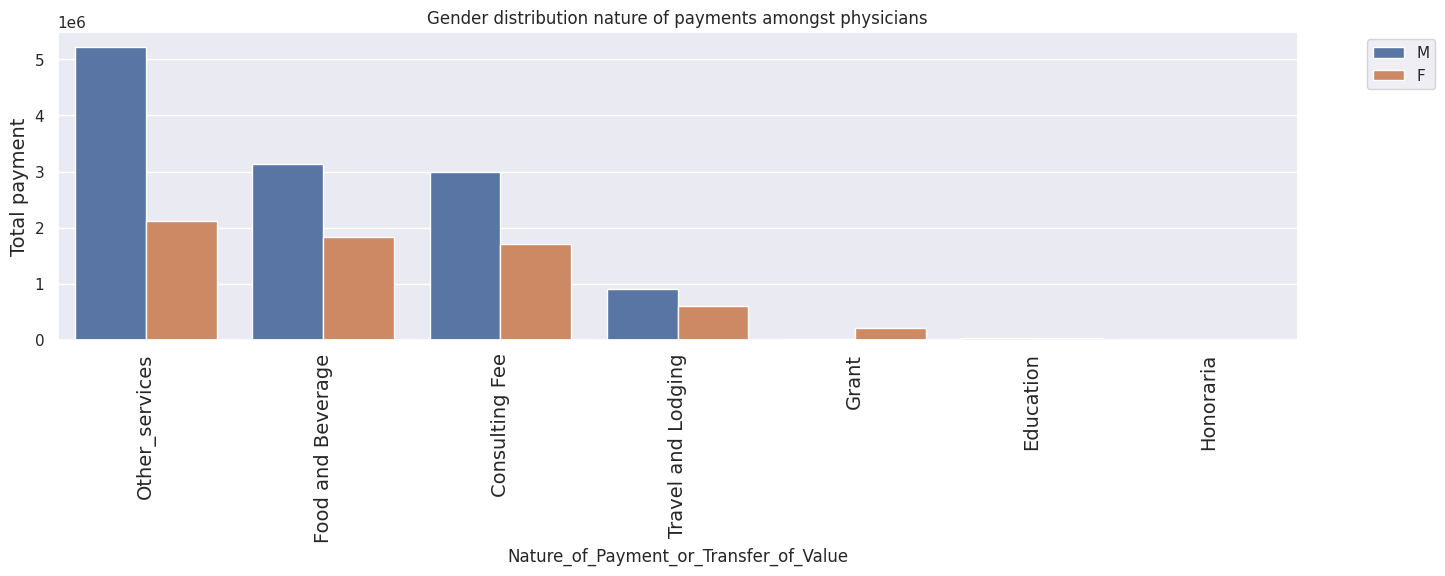

In [ ]:
my_palette=my_palette ={"F": "C1", "M": "C0"}

g=sns.barplot(data=nature_gender, x='Nature_of_Payment_or_Transfer_of_Value', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender distribution nature of payments amongst physicians")
g.figure.set_size_inches(16, 4)
plt.ylabel("Total payment", size=14)
plt.xticks(rotation=90, size=14)
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');

In [ ]:
# Distribution by gender for nature of payments
top_individual=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Profile_ID'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
top_individual

,Covered_Recipient_Profile_ID,Total_Amount_of_Payment_USDollars
0,684159.0,115976.18
1,26487.0,111701.80
2,281692.0,97454.31
3,959048.0,97155.32
4,11337343.0,75000.00
...,...,...
55639,353514.0,12.69
55640,254462.0,12.69
55641,1380005.0,12.69
55642,217990.0,12.69


In [ ]:
# Distribution by gender for nature of payments
nature_gender_individual=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Profile_ID','Nature_of_Payment_or_Transfer_of_Value','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nature_gender_individual


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,26487.0,Consulting Fee,M,89900.00
1,281692.0,Consulting Fee,M,77275.00
2,11337343.0,Grant,F,75000.00
3,684159.0,Consulting Fee,M,59920.50
4,313849.0,Other_services,M,56018.75
...,...,...,...,...
57493,285561.0,Education,M,2.26
57494,931265.0,Education,F,2.26
57495,88603.0,Education,M,2.26
57496,28828.0,Education,M,2.26


In [ ]:
## No 1 receiver
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']==26487.0]


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,26487.0,Consulting Fee,M,89900.00
176,26487.0,Travel and Lodging,M,20494.64
1188,26487.0,Food and Beverage,M,1307.16


In [ ]:
## No 2 receiver
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']==281692.0]


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
1,281692.0,Consulting Fee,M,77275.00
194,281692.0,Travel and Lodging,M,19588.49
1613,281692.0,Food and Beverage,M,590.82


In [ ]:
## No 3 receiver
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']==11337343.0]


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
2,11337343.0,Grant,F,75000.0


In [ ]:
## No 4 receiver
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']==684159.0]


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
3,684159.0,Consulting Fee,M,59920.50
27,684159.0,Other_services,M,47460.75
821,684159.0,Travel and Lodging,M,4606.38
1041,684159.0,Honoraria,M,2000.00
1046,684159.0,Food and Beverage,M,1988.55


In [ ]:
# No 5 receiver
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']==313849.0]


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
4,313849.0,Other_services,M,56018.75
781,313849.0,Travel and Lodging,M,4805.50
1410,313849.0,Food and Beverage,M,798.38


In [ ]:
## Reveivers of royalty
nature_gender_individual[nature_gender_individual['Nature_of_Payment_or_Transfer_of_Value']=='Royalty or License']


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars


In [ ]:
# No royalty receiver
# nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']==1314819.0]

In [ ]:
# Receivers of grant
nature_gender_individual[nature_gender_individual['Nature_of_Payment_or_Transfer_of_Value']=='Grant']


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
2,11337343.0,Grant,F,75000.00
55,3844375.0,Grant,F,40066.00
56,7576412.0,Grant,F,40000.00
132,1085128.0,Grant,F,25000.00
187,862176.0,Grant,F,19800.00
189,288354.0,Grant,M,19734.00
859,880513.0,Grant,F,3955.56
1371,336454.0,Grant,F,847.62
1372,285643.0,Grant,F,847.62


In [ ]:
# Honoraria
# Receivers of grant
nature_gender_individual[nature_gender_individual['Nature_of_Payment_or_Transfer_of_Value']=='Honoraria'].sort_values(by='Total_Amount_of_Payment_USDollars')



,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
1041,684159.0,Honoraria,M,2000.0
892,359697.0,Honoraria,F,3500.0


In [ ]:
# No grants given
# nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']==2185878.0]

In [ ]:
# No grants given
# nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']==1062101.0]

### Summary of observations for Novo nordisk.

Top level gender ratio is more female oriented.57.79%

**Physicians**

* The female count at physician level is 37.8%
* Average payment as phycian males is higher than females as medical doctor only, which is biggest category, making males overll higher.
* Other categoreis in which females get higher are Dentistry, chiropractor, osteopathy, optometery, podiatric medicine.

**Non Physicians**
* Gender ratio is reversed. Females are more, females are 82 % 
* Non-physicians females get at slighty higher on average.

**Amongst top 50 paid, only 16 are females.**
* Top earners are primarily paid for consultancy and other services (speaker in event). No Royalties were paid.
* 9 grants were paid. All females , 1 male (19,734) . Values varied from 847 usd to 75,000 usd. 4 grants were substancial 25,000 to 75,000$.
* 2 honoraria, 1 Male and 1 female. 2000 usd, 3500 usd. Not substancial.
